<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/encoder_attention_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_c03d989b55c966d18c971a92b023645b"

!kaggle datasets download -d britikak/busi-dataset



Dataset URL: https://www.kaggle.com/datasets/britikak/busi-dataset
License(s): unknown
100% 195M/195M [00:01<00:00, 148MB/s]



In [ ]:
!unzip -q busi-dataset.zip -d busi_dataset

In [ ]:
!pip install segmentation_models_pytorch

import os
import copy
import torch
import random
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import albumentations as A
from tqdm import tqdm
import segmentation_models_pytorch as smp

BASE_DIR = "/content/busi_dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant"]
IMG_SIZE = 256
BATCH_SIZE = 8
SEED = 42
EPOCHS = 100

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00


In [ ]:
class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform

        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)
            images = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "_mask" not in f]

            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")

                mask_files = [f for f in os.listdir(cls_dir) if f.startswith(base_name + "_mask") and f.endswith(".png")]
                if len(mask_files) == 0:
                    continue

                mask_paths = [os.path.join(cls_dir, f) for f in mask_files]
                self.samples.append((img_path, mask_paths))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))

        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            mask = (mask > 0).astype(np.uint8)
            combined_mask = np.logical_or(combined_mask, mask)

        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image = augmented["image"]
            combined_mask = augmented["mask"]

        combined_mask = (combined_mask > 0.5).astype(np.float32)
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(combined_mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)
total_size = len(full_dataset)
indices = list(range(total_size))

np.random.shuffle(indices)

train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)

train_indices = indices[val_size:train_size + val_size]
val_indices = indices[:val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=train_transform), train_indices)
val_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform), val_indices)
test_dataset = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform), test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        preds = torch.sigmoid(logits)
        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / (preds_f.sum() + targets_f.sum() + self.smooth)
        return 0.5 * bce_loss + 0.5 * dice_loss

def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()
    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter
    return inter / (union + eps)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
).to(device)

criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


Starting training for 10 epochs...



Epoch 1/10 [Val]: 100%|██████████| 8/8 [00:00<00:00, 10.64it/s]



Epoch 1: Train Loss: 0.6686 | Val Loss: 0.5664
Train Dice: 0.2330 | Val Dice: 0.3088
✓ Best model saved at Epoch 1 (Val Loss: 0.5664)


Epoch 2/10 [Val]: 100%|██████████| 8/8 [00:00<00:00, 10.98it/s]



Epoch 2: Train Loss: 0.5321 | Val Loss: 0.4822
Train Dice: 0.3271 | Val Dice: 0.3736
✓ Best model saved at Epoch 2 (Val Loss: 0.4822)


...


Epoch 8: Train Loss: 0.2854 | Val Loss: 0.2758
Train Dice: 0.5823 | Val Dice: 0.5859
✓ Best model saved at Epoch 8 (Val Loss: 0.2758)


Epoch 9/10 [Val]: 100%|██████████| 8/8 [00:00<00:00, 10.87it/s]



Epoch 9: Train Loss: 0.2863 | Val Loss: 0.2841
Train Dice: 0.5836 | Val Dice: 0.5866


Epoch 10/10 [Val]: 100%|██████████| 8/8 [00:00<00:00, 10.58it/s]



Epoch 10: Train Loss: 0.2587 | Val Loss: 0.2586
Train Dice: 0.6200 | Val Dice: 0.6133
✓ Best model saved at Epoch 10 (Val Loss: 0.2586)

Training Complete!
Best Validation Loss: 0.2586 (Achieved at Epoch 10)



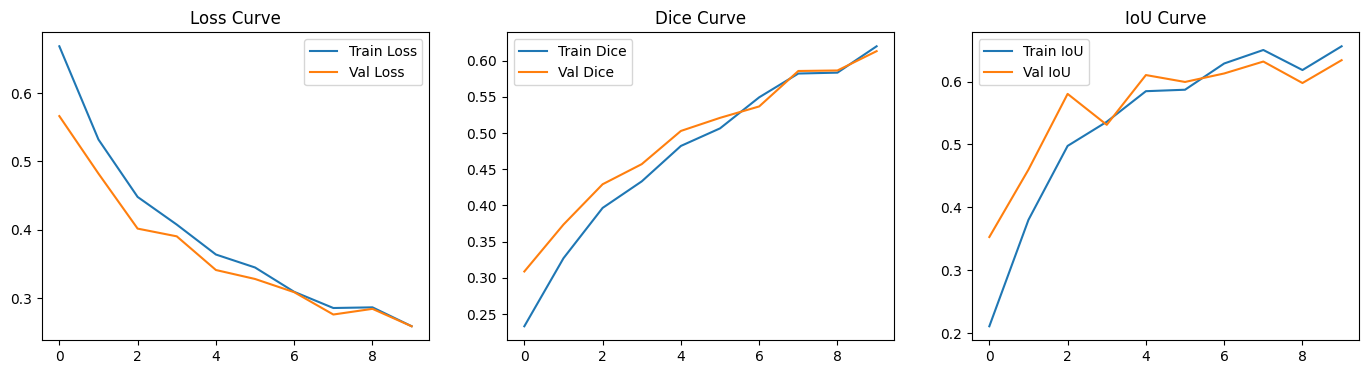


Evaluating Best Model on the Unseen Test Set...


[Test]: 100%|██████████| 9/9 [00:00<00:00, 11.49it/s]


 Final Test Results (from Epoch 10):
Test Loss: 0.2822 | Test Dice: 0.5478 | Test IoU: 0.5845


In [ ]:

EPOCHS = 10

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []
train_iou_scores, val_iou_scores = [], []

best_val_loss = float("inf")
best_model_weights = None
best_epoch = 0

print(f"\nStarting training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):

    # training
    model.train()
    train_loss = train_dice = train_iou = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds_prob = torch.sigmoid(logits)
        train_loss += loss.item()
        train_dice += dice_coef(masks, preds_prob).item()
        train_iou += iou_score(preds_prob, masks)

    # val
    model.eval()
    val_loss = val_dice = val_iou = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(device), masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            preds_prob = torch.sigmoid(logits)
            val_loss += loss.item()
            val_dice += dice_coef(masks, preds_prob).item()
            val_iou += iou_score(preds_prob, masks)

    # calc
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice / len(val_loader)
    avg_train_iou  = train_iou / len(train_loader)
    avg_val_iou    = val_iou / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dice_scores.append(avg_train_dice)
    val_dice_scores.append(avg_val_dice)
    train_iou_scores.append(avg_train_iou)
    val_iou_scores.append(avg_val_iou)

    print(f"\nEpoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")

    # best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_smp_unet.pth")
        print(f"✓ Best model saved at Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")

    scheduler.step(avg_val_loss)

print("\n" + "="*50)
print("Training Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f} (Achieved at Epoch {best_epoch})")
print("="*50 + "\n")

# Load the best weights before testing
model.load_state_dict(best_model_weights)


plt.figure(figsize=(17, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_dice_scores, label="Train Dice")
plt.plot(val_dice_scores, label="Val Dice")
plt.title("Dice Curve")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_iou_scores, label="Train IoU")
plt.plot(val_iou_scores, label="Val IoU")
plt.title("IoU Curve")
plt.legend()

plt.savefig("training_curves_smp.png", dpi=300, bbox_inches='tight')
plt.show()

# test

print("\n" + "="*50)
print("Evaluating Best Model on the Unseen Test Set...")
print("="*50)

model.eval()
test_loss = test_dice = test_iou = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="[Test]"):
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds_prob = torch.sigmoid(logits)
        test_loss += loss.item()
        test_dice += dice_coef(masks, preds_prob).item()
        test_iou += iou_score(preds_prob, masks)

avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)
avg_test_iou  = test_iou / len(test_loader)

print(f"\n Final Test Results (from Epoch {best_epoch}):")
print(f"Test Loss: {avg_test_loss:.4f} | Test Dice: {avg_test_dice:.4f} | Test IoU: {avg_test_iou:.4f}")